In [ ]:

import sys
import subprocess
import importlib.util
import re
import os
import pandas as pd
import numpy as np



def install_if_missing(package_name, import_name=None):
    import_name = import_name or package_name
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing {package_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])

install_if_missing("transformers")
install_if_missing("torch")
install_if_missing("torchvision")
install_if_missing("scikit-learn", "sklearn")
install_if_missing("pandas")
install_if_missing("matplotlib")
install_if_missing("tqdm")
install_if_missing("pillow", "PIL")

In [ ]:

import os
import json
import random
from dataclasses import dataclass


import numpy as np
import pandas as pd
from PIL import Image, ImageFile
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from transformers import CLIPProcessor, CLIPModel
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

ImageFile.LOAD_TRUNCATED_IMAGES = True


c:\Users\ezetaxe\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\ezetaxe\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\ezetaxe\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/f

In [ ]:

@dataclass
class Config:

    COCO_ROOT = r"C:\Users\ezetaxe\Downloads\mscoco2017"

    TRAIN_IMG_DIR = "train2017"
    VAL_IMG_DIR = "val2017"

    TRAIN_CAPTIONS = r"annotations\captions_train2017.json"
    VAL_CAPTIONS = r"annotations\captions_val2017.json"

    MAX_TRAIN_IMAGES = 50000
    MAX_VAL_IMAGES = 10000

    TRAIN_FRACTIONS = (0.1, 0.2, 0.5, 1.0)

    CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"

    EPOCHS = 7
    BATCH_SIZE = 128
    LR = 1e-3
    WEIGHT_DECAY = 1e-4

    IMAGE_EMBED_BATCH_SIZE = 32
    TEXT_EMBED_BATCH_SIZE = 128

    SEED = 1

    OUTPUT_DIR = r"C:\Users\ezetaxe\Downloads\ccs2_results"

cfg = Config()

In [ ]:

def set_seed(seed=1):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(cfg.SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

def check_coco_paths(cfg):
    required_paths = [
        os.path.join(cfg.COCO_ROOT, cfg.TRAIN_IMG_DIR),
        os.path.join(cfg.COCO_ROOT, cfg.VAL_IMG_DIR),
        os.path.join(cfg.COCO_ROOT, cfg.TRAIN_CAPTIONS),
        os.path.join(cfg.COCO_ROOT, cfg.VAL_CAPTIONS),
    ]

    missing = [p for p in required_paths if not os.path.exists(p)]

    if missing:
        print("\nERROR: Some required COCO paths were not found:")
        for p in missing:
            print("Missing:", p)

        print("\nExpected folder structure:")
        print("""
/path/to/coco2017/
    train2017/
    val2017/
    annotations/
        captions_train2017.json
        captions_val2017.json
        """)

        raise FileNotFoundError("Please update cfg.COCO_ROOT or check your dataset folder.")
    else:
        print("All COCO paths found.")

check_coco_paths(cfg)

Device: cpu
All COCO paths found.


In [ ]:

def load_coco_one_caption_per_image(coco_root, image_dir, captions_file, max_images=None, seed=1):
    """
    Loads one caption per image from COCO.
    Returns a DataFrame:
    image_id, image_path, caption
    """
    captions_path = os.path.join(coco_root, captions_file)
    img_dir = os.path.join(coco_root, image_dir)

    with open(captions_path, "r") as f:
        data = json.load(f)

    image_id_to_file = {
        img["id"]: img["file_name"]
        for img in data["images"]
    }

    image_id_to_captions = {}
    for ann in data["annotations"]:
        image_id = ann["image_id"]
        caption = ann["caption"]
        image_id_to_captions.setdefault(image_id, []).append(caption)

    rows = []

    for image_id, file_name in image_id_to_file.items():
        if image_id not in image_id_to_captions:
            continue

        image_path = os.path.join(img_dir, file_name)

        if not os.path.exists(image_path):
            continue

        caption = image_id_to_captions[image_id][0]

        rows.append({
            "image_id": image_id,
            "image_path": image_path,
            "caption": caption
        })

    df = pd.DataFrame(rows)
    df = df.sample(frac=1, random_state=seed).reset_index(drop=True)

    if max_images is not None:
        df = df.head(max_images).reset_index(drop=True)

    return df

print("\nLoading COCO metadata...")

train_base_df = load_coco_one_caption_per_image(
    coco_root=cfg.COCO_ROOT,
    image_dir=cfg.TRAIN_IMG_DIR,
    captions_file=cfg.TRAIN_CAPTIONS,
    max_images=cfg.MAX_TRAIN_IMAGES,
    seed=cfg.SEED
)

val_base_df = load_coco_one_caption_per_image(
    coco_root=cfg.COCO_ROOT,
    image_dir=cfg.VAL_IMG_DIR,
    captions_file=cfg.VAL_CAPTIONS,
    max_images=cfg.MAX_VAL_IMAGES,
    seed=cfg.SEED
)

print("Train images:", len(train_base_df))
print("Validation images:", len(val_base_df))
print(train_base_df.head())


Loading COCO metadata...
Train images: 50000
Validation images: 5000
   image_id                                         image_path  \
0    303308  C:\Users\ezetaxe\Downloads\mscoco2017\train201...   
1    147961  C:\Users\ezetaxe\Downloads\mscoco2017\train201...   
2     85795  C:\Users\ezetaxe\Downloads\mscoco2017\train201...   
3    178236  C:\Users\ezetaxe\Downloads\mscoco2017\train201...   
4    188388  C:\Users\ezetaxe\Downloads\mscoco2017\train201...   

                                            caption  
0  A refrigerator freezer next to a stove top oven.  
1     a person is holding up food with a bite in it  
2        A young girl sits inside of a luggage bag.  
3           a man running up to hit the tennis ball  
4    a person with a snow board walking down a hill  


In [ ]:

def make_positive_negative_pairs(base_df, seed=1):
    """
    Creates a balanced dataset:
    positive: image + its real caption, label 1
    negative: image + random caption from another image, label 0
    """
    rng = np.random.default_rng(seed)
    df = base_df.copy().reset_index(drop=True)

    if len(df) < 2:
        raise ValueError("Need at least 2 images to create negative pairs.")

    positives = df.copy()
    positives["pair_caption"] = positives["caption"]
    positives["label"] = 1
    positives["pair_type"] = "positive"

    negative_indices = []

    for i in range(len(df)):
        j = rng.integers(0, len(df))
        while j == i:
            j = rng.integers(0, len(df))
        negative_indices.append(j)

    negatives = df.copy()
    negatives["pair_caption"] = df.iloc[negative_indices]["caption"].values
    negatives["negative_source_image_id"] = df.iloc[negative_indices]["image_id"].values
    negatives["label"] = 0
    negatives["pair_type"] = "negative"

    pair_df = pd.concat([positives, negatives], ignore_index=True)
    pair_df = pair_df.sample(frac=1, random_state=seed).reset_index(drop=True)

    return pair_df

example_pairs = make_positive_negative_pairs(train_base_df.head(5), seed=cfg.SEED)
print("\nExample pairs:")
print(example_pairs[["image_id", "caption", "pair_caption", "label", "pair_type"]])



Example pairs:
   image_id                                           caption  \
0    178236           a man running up to hit the tennis ball   
1    147961     a person is holding up food with a bite in it   
2    303308  A refrigerator freezer next to a stove top oven.   
3    303308  A refrigerator freezer next to a stove top oven.   
4     85795        A young girl sits inside of a luggage bag.   
5     85795        A young girl sits inside of a luggage bag.   
6    188388    a person with a snow board walking down a hill   
7    188388    a person with a snow board walking down a hill   
8    178236           a man running up to hit the tennis ball   
9    147961     a person is holding up food with a bite in it   

                                       pair_caption  label pair_type  
0  A refrigerator freezer next to a stove top oven.      0  negative  
1     a person is holding up food with a bite in it      1  positive  
2           a man running up to hit the tennis ball    

In [ ]:

clip_model = CLIPModel.from_pretrained(cfg.CLIP_MODEL_NAME).to(device)
clip_processor = CLIPProcessor.from_pretrained(cfg.CLIP_MODEL_NAME)
clip_model.eval()
print("Loaded:", cfg.CLIP_MODEL_NAME)


Loading CLIP model...


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Loaded: openai/clip-vit-base-patch32


In [ ]:

@torch.no_grad()
def compute_image_embeddings(image_paths, processor, model, batch_size=32, device="cuda"):
    embeddings = {}
    unique_paths = list(dict.fromkeys(image_paths))

    for i in tqdm(range(0, len(unique_paths), batch_size), desc="Image embeddings"):
        batch_paths = unique_paths[i:i + batch_size]

        images = []
        valid_paths = []

        for path in batch_paths:
            try:
                img = Image.open(path).convert("RGB")
                images.append(img)
                valid_paths.append(path)
            except Exception as e:
                print(f"Could not load image: {path}, error: {e}")

        if len(images) == 0:
            continue

        inputs = processor(images=images, return_tensors="pt", padding=True).to(device)
        feats = model.get_image_features(**inputs)
        feats = feats / feats.norm(dim=-1, keepdim=True)
        feats = feats.cpu().numpy()

        for path, emb in zip(valid_paths, feats):
            embeddings[path] = emb.astype(np.float32)

    return embeddings

@torch.no_grad()
def compute_text_embeddings(texts, processor, model, batch_size=128, device="cuda"):
    embeddings = {}
    unique_texts = list(dict.fromkeys(texts))

    for i in tqdm(range(0, len(unique_texts), batch_size), desc="Text embeddings"):
        batch_texts = unique_texts[i:i + batch_size]

        inputs = processor(
            text=batch_texts,
            return_tensors="pt",
            padding=True,
            truncation=True
        ).to(device)

        feats = model.get_text_features(**inputs)
        feats = feats / feats.norm(dim=-1, keepdim=True)
        feats = feats.cpu().numpy()

        for text, emb in zip(batch_texts, feats):
            embeddings[text] = emb.astype(np.float32)

    return embeddings

print("\nComputing embeddings...")

all_image_paths = (
    train_base_df["image_path"].tolist()
    + val_base_df["image_path"].tolist()
)

all_captions = (
    train_base_df["caption"].tolist()
    + val_base_df["caption"].tolist()
)

image_emb_dict = compute_image_embeddings(
    image_paths=all_image_paths,
    processor=clip_processor,
    model=clip_model,
    batch_size=cfg.IMAGE_EMBED_BATCH_SIZE,
    device=device
)

text_emb_dict = compute_text_embeddings(
    texts=all_captions,
    processor=clip_processor,
    model=clip_model,
    batch_size=cfg.TEXT_EMBED_BATCH_SIZE,
    device=device
)

print("Image embeddings:", len(image_emb_dict))
print("Text embeddings:", len(text_emb_dict))


Computing embeddings...


Image embeddings:   0%|          | 0/1719 [00:00<?, ?it/s]

Text embeddings:   0%|          | 0/419 [00:00<?, ?it/s]

Image embeddings: 55000
Text embeddings: 53571


In [ ]:

def build_text_features(pair_df, text_emb_dict):
    X = []
    y = []

    for _, row in pair_df.iterrows():
        caption = row["pair_caption"]

        if caption not in text_emb_dict:
            continue

        X.append(text_emb_dict[caption])
        y.append(row["label"])

    X = np.stack(X).astype(np.float32)
    y = np.array(y).astype(np.int64)

    return X, y

def build_multimodal_features(pair_df, image_emb_dict, text_emb_dict):
    X = []
    y = []

    for _, row in pair_df.iterrows():
        image_path = row["image_path"]
        caption = row["pair_caption"]

        if image_path not in image_emb_dict:
            continue

        if caption not in text_emb_dict:
            continue

        img_emb = image_emb_dict[image_path]
        txt_emb = text_emb_dict[caption]

        combined = np.concatenate([
            img_emb,
            txt_emb,
            np.abs(img_emb - txt_emb),
            img_emb * txt_emb
        ])

        X.append(combined)
        y.append(row["label"])

    X = np.stack(X).astype(np.float32)
    y = np.array(y).astype(np.int64)

    return X, y


In [ ]:

class SimpleClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, dropout=0.2):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 2)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:

# Training and eval

def train_classifier(
    X_train,
    y_train,
    X_val,
    y_val,
    input_dim,
    epochs=5,
    batch_size=128,
    lr=1e-3,
    weight_decay=1e-4,
    device="cuda",
    seed=1
):
    set_seed(seed)

    model = SimpleClassifier(input_dim=input_dim).to(device)

    train_ds = TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.long)
    )

    val_ds = TensorDataset(
        torch.tensor(X_val, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.long)
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    loss_fn = nn.CrossEntropyLoss()

    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        model.eval()
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                logits = model(xb)
                preds = torch.argmax(logits, dim=1).cpu().numpy()

                all_preds.extend(preds)
                all_labels.extend(yb.numpy())

        acc = accuracy_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds)

        history.append({
            "epoch": epoch,
            "train_loss": float(np.mean(train_losses)),
            "val_accuracy": acc,
            "val_f1": f1
        })

        print(
            f"Epoch {epoch}/{epochs} | "
            f"Loss: {np.mean(train_losses):.4f} | "
            f"Val Acc: {acc:.4f} | "
            f"Val F1: {f1:.4f}"
        )

    return model, pd.DataFrame(history)

def evaluate_classifier(model, X, y, batch_size=128, device="cuda"):
    ds = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.long)
    )

    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)

    model.eval()

    all_preds = []
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)

            logits = model(xb)
            probs = torch.softmax(logits, dim=1)[:, 1]
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(yb.numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)

    report = classification_report(all_labels, all_preds, digits=4)
    cm = confusion_matrix(all_labels, all_preds)

    return {
        "accuracy": acc,
        "f1": f1,
        "report": report,
        "confusion_matrix": cm,
        "preds": np.array(all_preds),
        "probs": np.array(all_probs),
        "labels": np.array(all_labels)
    }


In [ ]:


val_pair_df = make_positive_negative_pairs(val_base_df, seed=cfg.SEED)

X_val_text, y_val_text = build_text_features(val_pair_df, text_emb_dict)
X_val_mm, y_val_mm = build_multimodal_features(val_pair_df, image_emb_dict, text_emb_dict)

print("Validation text features:", X_val_text.shape)
print("Validation multimodal features:", X_val_mm.shape)

assert np.array_equal(y_val_text, y_val_mm)
y_val = y_val_text



Preparing validation set...
Validation text features: (10000, 512)
Validation multimodal features: (10000, 2048)


In [ ]:

all_results = []
all_histories = {}

n_total = len(train_base_df)

for frac in cfg.TRAIN_FRACTIONS:
    print("\n" + "=" * 80)
    print(f"TRAINING FRACTION: {frac}")
    print("=" * 80)

    n_images = max(2, int(n_total * frac))

    subset_df = train_base_df.head(n_images).reset_index(drop=True)

    print(f"Using {len(subset_df)} train images")
    print(f"Will create {len(subset_df) * 2} image-caption pairs")

    train_pair_df = make_positive_negative_pairs(
        subset_df,
        seed=cfg.SEED
    )

    X_train_text, y_train_text = build_text_features(train_pair_df, text_emb_dict)
    X_train_mm, y_train_mm = build_multimodal_features(train_pair_df, image_emb_dict, text_emb_dict)

    print("Text train features:", X_train_text.shape)
    print("Multimodal train features:", X_train_mm.shape)

    assert np.array_equal(y_train_text, y_train_mm)

    print("\nTraining TEXT-ONLY model")

    text_model, text_history = train_classifier(
        X_train=X_train_text,
        y_train=y_train_text,
        X_val=X_val_text,
        y_val=y_val,
        input_dim=X_train_text.shape[1],
        epochs=cfg.EPOCHS,
        batch_size=cfg.BATCH_SIZE,
        lr=cfg.LR,
        weight_decay=cfg.WEIGHT_DECAY,
        device=device,
        seed=cfg.SEED
    )

    text_eval = evaluate_classifier(
        text_model,
        X_val_text,
        y_val,
        batch_size=cfg.BATCH_SIZE,
        device=device
    )

    print("\nTraining MULTIMODAL model")

    mm_model, mm_history = train_classifier(
        X_train=X_train_mm,
        y_train=y_train_mm,
        X_val=X_val_mm,
        y_val=y_val,
        input_dim=X_train_mm.shape[1],
        epochs=cfg.EPOCHS,
        batch_size=cfg.BATCH_SIZE,
        lr=cfg.LR,
        weight_decay=cfg.WEIGHT_DECAY,
        device=device,
        seed=cfg.SEED
    )

    mm_eval = evaluate_classifier(
        mm_model,
        X_val_mm,
        y_val,
        batch_size=cfg.BATCH_SIZE,
        device=device
    )

    all_results.append({
        "train_fraction": frac,
        "train_images": len(subset_df),
        "train_pairs": len(train_pair_df),
        "model": "text_only",
        "accuracy": text_eval["accuracy"],
        "f1": text_eval["f1"]
    })

    all_results.append({
        "train_fraction": frac,
        "train_images": len(subset_df),
        "train_pairs": len(train_pair_df),
        "model": "multimodal",
        "accuracy": mm_eval["accuracy"],
        "f1": mm_eval["f1"]
    })

    all_histories[(frac, "text_only")] = text_history
    all_histories[(frac, "multimodal")] = mm_history

    with open(os.path.join(cfg.OUTPUT_DIR, f"text_report_frac_{frac}.txt"), "w") as f:
        f.write(text_eval["report"])
        f.write("\nConfusion matrix:\n")
        f.write(str(text_eval["confusion_matrix"]))

    with open(os.path.join(cfg.OUTPUT_DIR, f"multimodal_report_frac_{frac}.txt"), "w") as f:
        f.write(mm_eval["report"])
        f.write("\nConfusion matrix:\n")
        f.write(str(mm_eval["confusion_matrix"]))

    print("\nFinal results for fraction:", frac)
    print("Text-only accuracy:", text_eval["accuracy"])
    print("Multimodal accuracy:", mm_eval["accuracy"])

results_df = pd.DataFrame(all_results)

results_path = os.path.join(cfg.OUTPUT_DIR, "results_summary.csv")
results_df.to_csv(results_path, index=False)

print("\nSaved results to:", results_path)
print(results_df)



TRAINING FRACTION: 0.1
Using 5000 train images
Will create 10000 image-caption pairs
Text train features: (10000, 512)
Multimodal train features: (10000, 2048)

Training TEXT-ONLY model
Epoch 1/7 | Loss: 0.6942 | Val Acc: 0.5018 | Val F1: 0.2767
Epoch 2/7 | Loss: 0.6929 | Val Acc: 0.5005 | Val F1: 0.6595
Epoch 3/7 | Loss: 0.6929 | Val Acc: 0.5001 | Val F1: 0.5072
Epoch 4/7 | Loss: 0.6926 | Val Acc: 0.5013 | Val F1: 0.4969
Epoch 5/7 | Loss: 0.6926 | Val Acc: 0.4988 | Val F1: 0.5292
Epoch 6/7 | Loss: 0.6913 | Val Acc: 0.5015 | Val F1: 0.5590
Epoch 7/7 | Loss: 0.6902 | Val Acc: 0.5028 | Val F1: 0.3458

Training MULTIMODAL model
Epoch 1/7 | Loss: 0.5751 | Val Acc: 0.8910 | Val F1: 0.8845
Epoch 2/7 | Loss: 0.2844 | Val Acc: 0.9341 | Val F1: 0.9327
Epoch 3/7 | Loss: 0.1718 | Val Acc: 0.9512 | Val F1: 0.9518
Epoch 4/7 | Loss: 0.1287 | Val Acc: 0.9549 | Val F1: 0.9555
Epoch 5/7 | Loss: 0.1088 | Val Acc: 0.9592 | Val F1: 0.9593
Epoch 6/7 | Loss: 0.0913 | Val Acc: 0.9607 | Val F1: 0.9608
Epoch 

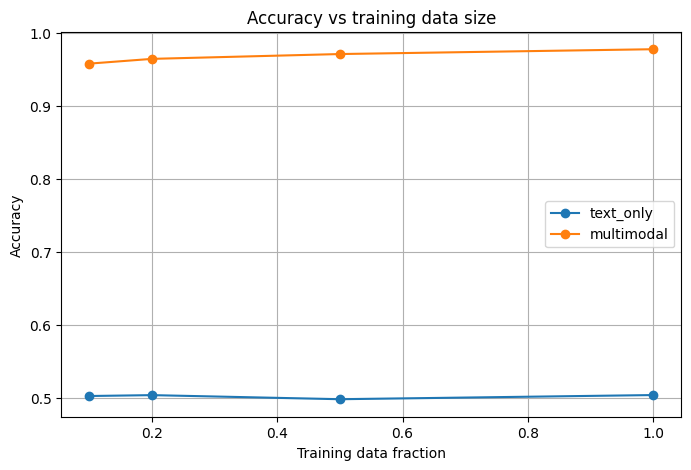

Saved plot to: C:\Users\ezetaxe\Downloads\ccs2_results\accuracy_vs_data_size.png


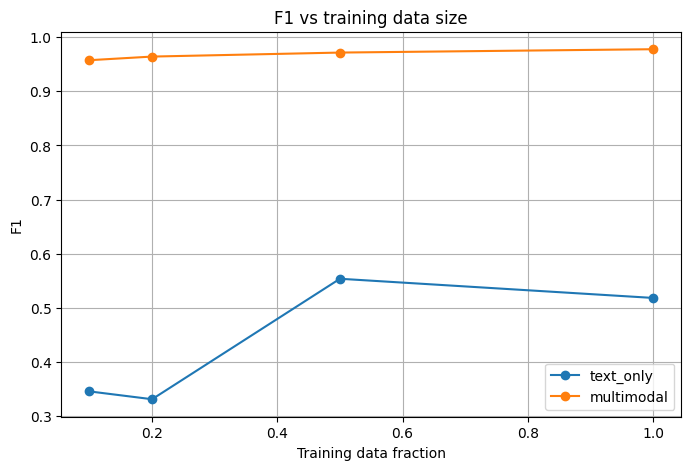

Saved plot to: C:\Users\ezetaxe\Downloads\ccs2_results\f1_vs_data_size.png


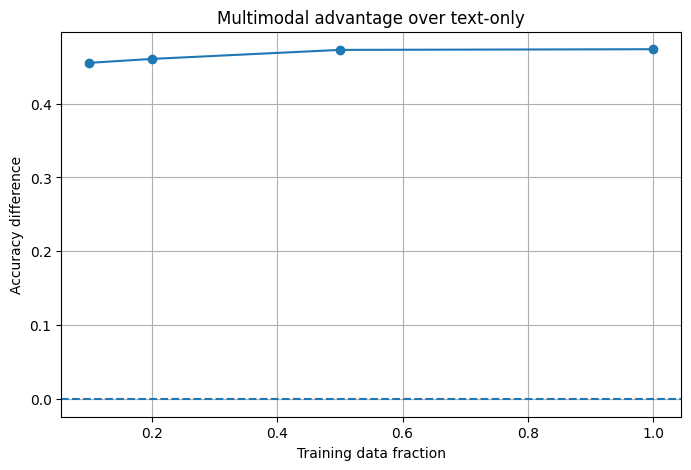

Saved plot to: C:\Users\ezetaxe\Downloads\ccs2_results\multimodal_advantage.png

Final pivot table:
model  train_fraction  multimodal  text_only  multimodal_advantage
0                 0.1      0.9579     0.5028                0.4551
1                 0.2      0.9644     0.5040                0.4604
2                 0.5      0.9710     0.4984                0.4726
3                 1.0      0.9776     0.5041                0.4735

Experiment complete.
All outputs saved to: C:\Users\ezetaxe\Downloads\ccs2_results


In [ ]:
# plots

def plot_metric(results_df, metric="accuracy"):
    plt.figure(figsize=(8, 5))

    for model_name in results_df["model"].unique():
        sub = results_df[results_df["model"] == model_name]

        plt.plot(
            sub["train_fraction"],
            sub[metric],
            marker="o",
            label=model_name
        )

    plt.xlabel("Training data fraction")
    plt.ylabel(metric.capitalize())
    plt.title(f"{metric.capitalize()} vs training data size")
    plt.legend()
    plt.grid(True)

    save_path = os.path.join(cfg.OUTPUT_DIR, f"{metric}_vs_data_size.png")
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved plot to:", save_path)

plot_metric(results_df, metric="accuracy")
plot_metric(results_df, metric="f1")

pivot_acc = results_df.pivot(
    index="train_fraction",
    columns="model",
    values="accuracy"
).reset_index()

pivot_acc["multimodal_advantage"] = pivot_acc["multimodal"] - pivot_acc["text_only"]

plt.figure(figsize=(8, 5))
plt.plot(
    pivot_acc["train_fraction"],
    pivot_acc["multimodal_advantage"],
    marker="o"
)

plt.axhline(0, linestyle="--")
plt.xlabel("Training data fraction")
plt.ylabel("Accuracy difference")
plt.title("Multimodal advantage over text-only")
plt.grid(True)

save_path = os.path.join(cfg.OUTPUT_DIR, "multimodal_advantage.png")
plt.savefig(save_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved plot to:", save_path)

print("\nFinal pivot table:")
print(pivot_acc)

print("\nExperiment complete.")
print("All outputs saved to:", cfg.OUTPUT_DIR)


In [ ]:


try:
    import spacy
except:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "spacy"])

try:
    nlp = spacy.load("en_core_web_sm")
except:
    subprocess.check_call([
        sys.executable,
        "-m",
        "spacy",
        "download",
        "en_core_web_sm"
    ])
    nlp = spacy.load("en_core_web_sm")

from collections import Counter
import pandas as pd
from tqdm.auto import tqdm

noun_counter = Counter()
verb_counter = Counter()
adj_counter = Counter()

captions = train_base_df["caption"].tolist()

print("Processing captions with spaCy...")

for caption in tqdm(captions):

    doc = nlp(caption.lower())

    for token in doc:

        # Ignore punctuation / stopwords
        if token.is_stop or token.is_punct:
            continue

        lemma = token.lemma_.lower()

        # NOUNS
        if token.pos_ in ["NOUN", "PROPN"]:
            noun_counter[lemma] += 1

        # VERBS
        elif token.pos_ == "VERB":
            verb_counter[lemma] += 1

        # ADJECTIVES
        elif token.pos_ == "ADJ":
            adj_counter[lemma] += 1


#  top words

TOP_K = 40

print("\n==============================")
print("TOP NOUNS")
print("==============================")

top_nouns = pd.DataFrame(
    noun_counter.most_common(TOP_K),
    columns=["noun", "count"]
)

display(top_nouns)

print("\n==============================")
print("TOP VERBS")
print("==============================")

top_verbs = pd.DataFrame(
    verb_counter.most_common(TOP_K),
    columns=["verb", "count"]
)

display(top_verbs)

print("\n==============================")
print("TOP ADJECTIVES")
print("==============================")

top_adjs = pd.DataFrame(
    adj_counter.most_common(TOP_K),
    columns=["adjective", "count"]
)

display(top_adjs)

Processing captions with spaCy...


  0%|          | 0/50000 [00:00<?, ?it/s]


TOP NOUNS


,noun,count
0,man,7671
1,people,3552
2,woman,3466
3,table,2916
4,street,2684
5,field,2115
6,group,2098
7,person,2052
8,plate,1862
9,dog,1859



TOP VERBS


,verb,count
0,sit,6547
1,stand,4639
2,hold,2995
3,rid,2139
4,walk,1586
5,play,1205
6,look,1147
7,fly,1098
8,park,1059
9,fill,1056



TOP ADJECTIVES


,adjective,count
0,white,3446
1,large,2216
2,young,1671
3,black,1667
4,small,1663
5,red,1622
6,green,1298
7,blue,1270
8,wooden,1006
9,brown,884


In [ ]:
FOIL_SWAPS = {
    # people
    "man": "woman",
    "woman": "man",
    "boy": "girl",
    "girl": "boy",
    "person": "man",

    # animals
    "dog": "cat",
    "cat": "dog",
    "horse": "bear",
    "bear": "horse",
    "giraffe": "horse",

    # vehicles
    "bus": "car",
    "car": "bus",
    "train": "bus",

    # objects
    "tennis": "baseball",
    "baseball": "tennis",
    "skateboard": "snowboard",
    "pizza": "plate",
    "bed": "bench",
    "bench": "bed",

    "plate": "bowl",
    "table": "bed",
    "room": "kitchen",
    "tree": "building",
    "clock": "sign",
    "ball": "pizza",
    "player": "person",
    "street": "field",
    "beach": "field",
    "bathroom": "kitchen",
}

In [17]:
print("Number of foil swaps:", len(FOIL_SWAPS))

print("\nFoil swaps:")
for k, v in FOIL_SWAPS.items():
    print(f"{k} -> {v}")

Number of foil swaps: 29

Foil swaps:
man -> woman
woman -> man
boy -> girl
girl -> boy
person -> man
dog -> cat
cat -> dog
horse -> bear
bear -> horse
giraffe -> horse
bus -> car
car -> bus
train -> bus
tennis -> baseball
baseball -> tennis
skateboard -> snowboard
pizza -> plate
bed -> bench
bench -> bed
plate -> bowl
table -> bed
room -> kitchen
tree -> building
clock -> sign
ball -> pizza
player -> person
street -> field
beach -> field
bathroom -> kitchen


In [ ]:
# foil eval


def replace_one_word_foil(caption, swaps):
    """
    Replace one selected noun/object word with a plausible foil word.
    Returns foil_caption, old_word, new_word.
    """

    words = caption.split()

    for i, word in enumerate(words):

        # separate punctuation from word
        match = re.match(r"^([^\w]*)([\w'-]+)([^\w]*)$", word)

        if not match:
            continue

        prefix, core, suffix = match.groups()
        clean = core.lower()

        if clean in swaps:
            replacement = swaps[clean]

            # preserve capitalization
            if core[0].isupper():
                replacement = replacement.capitalize()

            new_words = words.copy()
            new_words[i] = prefix + replacement + suffix

            foil_caption = " ".join(new_words)

            return foil_caption, core, replacement

    return None, None, None


def make_foil_it_dataset(base_df, swaps):
    """
    Creates a foil validation dataset:
    positive: image + original caption -> label 1
    foil: image + minimally changed caption -> label 0
    """

    rows = []

    for _, row in base_df.iterrows():

        original_caption = row["caption"]

        foil_caption, old_word, new_word = replace_one_word_foil(
            original_caption,
            swaps
        )

        # skip captions where no foil could be generated
        if foil_caption is None:
            continue

        # positive example
        rows.append({
            "image_id": row["image_id"],
            "image_path": row["image_path"],
            "caption": original_caption,
            "pair_caption": original_caption,
            "label": 1,
            "pair_type": "positive",
            "replaced_word": None,
            "replacement_word": None
        })

        # foil negative example
        rows.append({
            "image_id": row["image_id"],
            "image_path": row["image_path"],
            "caption": original_caption,
            "pair_caption": foil_caption,
            "label": 0,
            "pair_type": "foil",
            "replaced_word": old_word,
            "replacement_word": new_word
        })

    foil_df = pd.DataFrame(rows)
    foil_df = foil_df.sample(frac=1, random_state=cfg.SEED).reset_index(drop=True)

    return foil_df



foil_val_df = make_foil_it_dataset(val_base_df, FOIL_SWAPS)

print("Foil dataset created.")
print("Total foil validation rows:", len(foil_val_df))
print("Positive rows:", (foil_val_df["label"] == 1).sum())
print("Foil rows:", (foil_val_df["label"] == 0).sum())

coverage = (foil_val_df["label"] == 0).sum() / len(val_base_df)

print(f"Coverage of original validation captions: {coverage:.2%}")

print("\nExample foil pairs:")
display(
    foil_val_df[
        ["caption", "pair_caption", "label", "pair_type", "replaced_word", "replacement_word"]
    ].head(20)
)

replacement_counts = (
    foil_val_df[foil_val_df["pair_type"] == "foil"]
    .groupby(["replaced_word", "replacement_word"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print("\nMost common foil replacements:")
display(replacement_counts.head(20))



foil_text_emb_dict = text_emb_dict.copy()

all_foil_captions = foil_val_df["pair_caption"].unique().tolist()
new_foil_captions = [
    c for c in all_foil_captions
    if c not in foil_text_emb_dict
]

print("\nNew foil captions requiring CLIP text embeddings:", len(new_foil_captions))

if len(new_foil_captions) > 0:
    new_foil_embs = compute_text_embeddings(
        texts=new_foil_captions,
        processor=clip_processor,
        model=clip_model,
        batch_size=cfg.TEXT_EMBED_BATCH_SIZE,
        device=device
    )

    foil_text_emb_dict.update(new_foil_embs)


X_foil_text, y_foil_text = build_text_features(
    foil_val_df,
    foil_text_emb_dict
)

X_foil_mm, y_foil_mm = build_multimodal_features(
    foil_val_df,
    image_emb_dict,
    foil_text_emb_dict
)

print("\nFoil text features:", X_foil_text.shape)
print("Foil multimodal features:", X_foil_mm.shape)

assert np.array_equal(y_foil_text, y_foil_mm)


# eval

foil_text_eval = evaluate_classifier(
    text_model,
    X_foil_text,
    y_foil_text,
    batch_size=cfg.BATCH_SIZE,
    device=device
)

foil_mm_eval = evaluate_classifier(
    mm_model,
    X_foil_mm,
    y_foil_mm,
    batch_size=cfg.BATCH_SIZE,
    device=device
)


print("\n==============================")
print("FOIL-IT STYLE EVALUATION")
print("==============================")

print("\nText-only model:")
print("Accuracy:", foil_text_eval["accuracy"])
print("F1:", foil_text_eval["f1"])

print("\nMultimodal model:")
print("Accuracy:", foil_mm_eval["accuracy"])
print("F1:", foil_mm_eval["f1"])

print("\nText-only classification report:")
print(foil_text_eval["report"])

print("\nMultimodal classification report:")
print(foil_mm_eval["report"])



foil_results = pd.DataFrame([
    {
        "model": "text_only",
        "accuracy": foil_text_eval["accuracy"],
        "f1": foil_text_eval["f1"],
        "num_examples": len(y_foil_text),
        "coverage": coverage
    },
    {
        "model": "multimodal",
        "accuracy": foil_mm_eval["accuracy"],
        "f1": foil_mm_eval["f1"],
        "num_examples": len(y_foil_mm),
        "coverage": coverage
    }
])

foil_results_path = os.path.join(cfg.OUTPUT_DIR, "foil_it_results.csv")
foil_examples_path = os.path.join(cfg.OUTPUT_DIR, "foil_it_examples.csv")
replacement_counts_path = os.path.join(cfg.OUTPUT_DIR, "foil_replacement_counts.csv")

foil_results.to_csv(foil_results_path, index=False)
foil_val_df.to_csv(foil_examples_path, index=False)
replacement_counts.to_csv(replacement_counts_path, index=False)

print("\nSaved foil results to:", foil_results_path)
print("Saved foil examples to:", foil_examples_path)
print("Saved replacement counts to:", replacement_counts_path)

display(foil_results)

Foil dataset created.
Total foil validation rows: 6202
Positive rows: 3101
Foil rows: 3101
Coverage of original validation captions: 62.02%

Example foil pairs:


,caption,pair_caption,label,pair_type,replaced_word,replacement_word
0,A double decker bus is shown that is not in se...,A double decker car is shown that is not in se...,0,foil,bus,car
1,A cat standing on the edge of a sink drink water.,A dog standing on the edge of a sink drink water.,0,foil,cat,dog
2,A baseball player throwing a pitch onto the field,A tennis player throwing a pitch onto the field,0,foil,baseball,tennis
3,A cat sprawled out over the top of a laptop co...,A dog sprawled out over the top of a laptop co...,0,foil,cat,dog
4,A city street filled with lots of traffic and ...,A city field filled with lots of traffic and l...,0,foil,street,field
5,A baseball player standing on the field in uni...,A baseball player standing on the field in uni...,1,positive,None,None
6,Man and boys holding two surfboards getting pi...,Woman and boys holding two surfboards getting ...,0,foil,Man,Woman
7,A boy doing a skateboard trick on a street.,A girl doing a skateboard trick on a street.,0,foil,boy,girl
8,A bunch of bananas on a plate on a counter.,A bunch of bananas on a bowl on a counter.,0,foil,plate,bowl
9,A close-up picture of a man wearing a tie.,A close-up picture of a woman wearing a tie.,0,foil,man,woman



Most common foil replacements:


,replaced_word,replacement_word,count
47,man,woman,581
59,woman,man,255
48,person,man,199
54,street,field,171
55,table,bed,170
41,cat,dog,137
50,plate,bowl,126
57,train,bus,124
52,room,kitchen,117
43,dog,cat,111



New foil captions requiring CLIP text embeddings: 3021


Text embeddings:   0%|          | 0/24 [00:00<?, ?it/s]


Foil text features: (6202, 512)
Foil multimodal features: (6202, 2048)

FOIL-IT STYLE EVALUATION

Text-only model:
Accuracy: 0.5032247662044502
F1: 0.5209143212564142

Multimodal model:
Accuracy: 0.5509513060303128
F1: 0.6865503657850309

Text-only classification report:
              precision    recall  f1-score   support

           0     0.5035    0.4663    0.4842      3101
           1     0.5030    0.5401    0.5209      3101

    accuracy                         0.5032      6202
   macro avg     0.5032    0.5032    0.5025      6202
weighted avg     0.5032    0.5032    0.5025      6202


Multimodal classification report:
              precision    recall  f1-score   support

           0     0.8780    0.1183    0.2086      3101
           1     0.5273    0.9836    0.6866      3101

    accuracy                         0.5510      6202
   macro avg     0.7027    0.5510    0.4476      6202
weighted avg     0.7027    0.5510    0.4476      6202


Saved foil results to: C:\Users\ezeta

,model,accuracy,f1,num_examples,coverage
0,text_only,0.503225,0.520914,6202,0.6202
1,multimodal,0.550951,0.686550,6202,0.6202


In [ ]:

foil_base_df = load_coco_one_caption_per_image(
    coco_root=cfg.COCO_ROOT,
    image_dir=cfg.VAL_IMG_DIR,
    captions_file=cfg.VAL_CAPTIONS,
    max_images=9000,   # scale 
)

print("Foil base images:", len(foil_base_df))

Foil base images: 5000


In [20]:
foil_val_df = make_foil_it_dataset(
    foil_base_df,
    FOIL_SWAPS
)

print("Foil dataset rows:", len(foil_val_df))
print("Positive examples:", (foil_val_df["label"] == 1).sum())
print("Foil examples:", (foil_val_df["label"] == 0).sum())
print("Coverage:", (foil_val_df["label"] == 0).sum() / len(foil_base_df))

Foil dataset rows: 6202
Positive examples: 3101
Foil examples: 3101
Coverage: 0.6202


In [ ]:


extra_foil_image_paths = [
    p for p in foil_base_df["image_path"].tolist()
    if p not in image_emb_dict
]

print("Extra foil images needing embeddings:", len(extra_foil_image_paths))

if len(extra_foil_image_paths) > 0:
    extra_image_embs = compute_image_embeddings(
        image_paths=extra_foil_image_paths,
        processor=clip_processor,
        model=clip_model,
        batch_size=cfg.IMAGE_EMBED_BATCH_SIZE,
        device=device
    )

    image_emb_dict.update(extra_image_embs)

print("Total image embeddings now:", len(image_emb_dict))

Extra foil images needing embeddings: 0
Total image embeddings now: 55000


In [ ]:


X_foil_text, y_foil_text = build_text_features(
    foil_val_df,
    foil_text_emb_dict
)

X_foil_mm, y_foil_mm = build_multimodal_features(
    foil_val_df,
    image_emb_dict,
    foil_text_emb_dict
)

print("Foil text features:", X_foil_text.shape)
print("Foil multimodal features:", X_foil_mm.shape)

Foil text features: (6202, 512)
Foil multimodal features: (6202, 2048)


In [ ]:
# eval

foil_text_eval = evaluate_classifier(
    text_model,
    X_foil_text,
    y_foil_text,
    batch_size=cfg.BATCH_SIZE,
    device=device
)

foil_mm_eval = evaluate_classifier(
    mm_model,
    X_foil_mm,
    y_foil_mm,
    batch_size=cfg.BATCH_SIZE,
    device=device
)


print("\nText-only:")
print("Accuracy:", foil_text_eval["accuracy"])
print("F1:", foil_text_eval["f1"])

print("\nMultimodal:")
print("Accuracy:", foil_mm_eval["accuracy"])
print("F1:", foil_mm_eval["f1"])


UPDATED FOIL EVALUATION

Text-only:
Accuracy: 0.5032247662044502
F1: 0.5209143212564142

Multimodal:
Accuracy: 0.5509513060303128
F1: 0.6865503657850309


In [ ]:
print("\nTEXT-ONLY REPORT")
print(foil_text_eval["report"])

print("\nMULTIMODAL REPORT")
print(foil_mm_eval["report"])


TEXT-ONLY REPORT
              precision    recall  f1-score   support

           0     0.5035    0.4663    0.4842      3101
           1     0.5030    0.5401    0.5209      3101

    accuracy                         0.5032      6202
   macro avg     0.5032    0.5032    0.5025      6202
weighted avg     0.5032    0.5032    0.5025      6202


MULTIMODAL REPORT
              precision    recall  f1-score   support

           0     0.8780    0.1183    0.2086      3101
           1     0.5273    0.9836    0.6866      3101

    accuracy                         0.5510      6202
   macro avg     0.7027    0.5510    0.4476      6202
weighted avg     0.7027    0.5510    0.4476      6202

